llm和增强

In [4]:
# Schema for structured output
from pydantic import BaseModel, Field

from langchain_community.chat_models import ChatTongyi


llm = ChatTongyi(
    model="qwen3-max",
    api_key="sk-2a858e00fb8e4a2a89fd542747543efe",
)


class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")

# Get the tool call
msg.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_f82a9ec3102444f88cdeeff7',
  'type': 'tool_call'}]

workflow

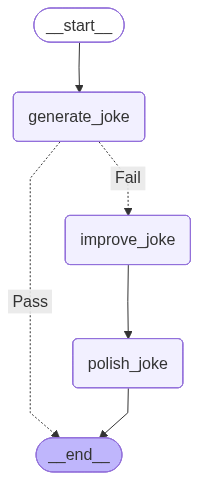

Initial joke:
为什么猫不喜欢上网？  
因为它们怕遇到鼠标！ 😺

--- --- ---

Improved joke:
为什么猫不喜欢上网？  
因为一上线就“鼠”于它们的噩梦——  
不仅怕遇到鼠标，还怕点开“猫”腻链接！ 😼💻🐭

（双关解析：  
1. “鼠”于 = “属”于 + 鼠标（谐音梗）  
2. “猫腻” = 本义指可疑之处，字面又含“猫”，暗示网络陷阱专坑喵星人！）

--- --- ---

Final joke:
当然可以！这里是一个加入**意想不到反转**的升级版，保留原有双关，再添一层“猫设崩塌”的惊喜：

---

**为什么猫不喜欢上网？**  
因为一上线就“鼠”于它们的噩梦——  
不仅怕遇到鼠标，还怕点开“猫”腻链接！ 😼💻🐭  

**结果你猜怎么着？**  
**其实它们偷偷注册了小号，专刷“铲屎官驯养教程”……  
现在全网都在教人类：如何心甘情愿当猫奴！** 🐾👑

---

### ✨ 扭转点解析：
- **前半段**延续原梗（怕鼠标/猫腻链接），维持熟悉感；  
- **后半段突然反转**：猫不是受害者，而是**幕后操控者**！表面嫌弃网络，实则暗中用互联网“驯化人类”，把“被服务”变成主动战略；  
- **“铲屎官驯养教程”** 双关人类自嘲的“猫奴”身份 + 猫的狩猎本能（驯养=捕获）；  
- 结尾 **👑** 暗示猫才是真正的“网络霸主”，颠覆传统人宠关系，荒诞又合理！

这样既保留了原笑话的谐音巧思，又用“猫の阳谋”制造意外笑点，符合“表面怕网→实则控网”的反转逻辑～


In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build app
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show app
display(Image(chain.get_graph().draw_mermaid_png()))

# Invoke
state = chain.invoke({"topic": "猫"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

并行化

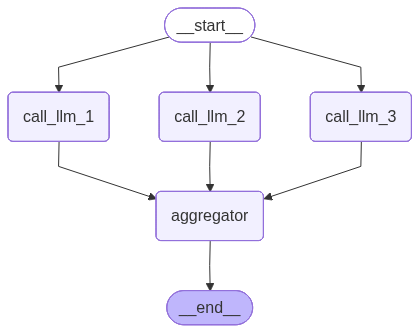

Here's a story, joke, and poem about 猫!

STORY:
## 猫的契约

雨点砸在废弃仓库锈蚀的铁皮屋顶上，发出沉闷而持续的鼓声。阿灰蜷缩在角落一堆发霉的麻袋里，雨水顺着破洞滴落，在它灰白相间的皮毛上洇开深色的印记。它瘦得肋骨清晰可见，琥珀色的眼睛在昏暗中警惕地转动，捕捉着每一丝异响——老鼠窸窣的爬行、远处野狗模糊的吠叫，还有那若有若无、令它脊背发凉的饥饿感。

突然，一阵更急促的脚步声由远及近，踩碎了雨声的单调。阿灰瞬间绷紧身体，喉咙里滚出低沉的警告。一个湿透的身影踉跄着冲进仓库深处，是个人类少年，约莫十四五岁，校服被雨水浸透，紧紧贴在单薄的身体上，脸上混杂着惊惶与一种近乎绝望的倔强。他喘息着，背靠着冰冷的墙壁滑坐在地，目光茫然地扫过黑暗，最终，落在了阿灰藏身的角落。

阿灰的瞳孔骤然收缩成一条细线。人类！危险！它本能地弓起背，炸开颈毛，喉咙里的呼噜声变成了威胁的嘶鸣。少年却只是疲惫地闭上眼，喃喃自语：“完了……全完了……”声音里带着哭腔，像被抽走了所有力气。

阿灰的耳朵动了动。那声音里的绝望，竟奇异地压过了它对人类的恐惧。它犹豫着，没有立刻逃开。少年摸索着口袋，掏出半块被雨水泡软的面包，掰下一小块，轻轻放在离自己不远的地上。“吃吧，”他声音沙哑，“反正……也没用了。”说完，他又颓然靠回墙边，眼神空洞地望着漏雨的屋顶。

那微弱的食物香气像无形的钩子，勾住了阿灰的胃。它小心翼翼地挪动，每一步都带着试探，眼睛死死盯着少年。终于，在距离面包仅一步之遥时，它闪电般探出头，叼起那小块面包，迅速退回到麻袋阴影里。温热的、带着雨水和人类气息的面包屑在嘴里化开，久违的暖意从胃里升腾起来。它偷偷抬眼，看到少年正看着它，眼神里没有驱赶，只有一种同病相怜的疲惫。

雨声渐歇，仓库里只剩下两人一猫粗重的呼吸。少年挣扎着坐直了些，从书包里掏出一张皱巴巴的纸，上面印着“退学通知”几个刺目的红字。他把它揉成一团，狠狠砸向远处，动作带着少年人特有的激烈，却又在下一秒泄了气，肩膀垮塌下来，无声地颤抖。

阿灰默默地看着。它不懂那些符号，却懂得那种被世界抛弃的冰冷。它犹豫片刻，竟慢慢踱步过去，在少年脚边停下，仰起头，用脑袋轻轻蹭了蹭少年冰凉的手背。那触感柔软而温暖，带着生灵特有的慰藉。少年愣住了，低头看着这只主动靠近的流浪猫，浑浊的眼底似乎有微光闪动。他迟

In [8]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build app
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show app
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "猫"})
print(state["combined_output"])

路由

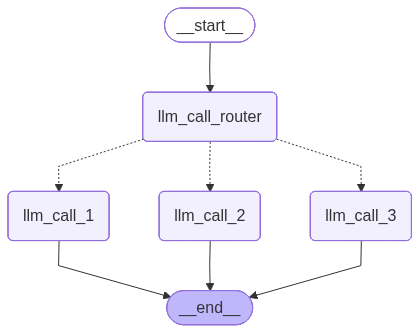

{'llm_call_router': {'decision': 'story'}}
{'llm_call_1': {'output': '## 窗台上的小橘\n\n暴雨如注，狠狠砸在废弃仓库锈迹斑斑的铁皮屋顶上，发出震耳欲聋的轰鸣。雨水从破洞处倾泻而下，在泥泞的地面上汇成浑浊的小溪。小橘蜷缩在角落一堆湿透的破布里，浑身湿透，瑟瑟发抖。它瘦得几乎能数清肋骨，唯有那双琥珀色的大眼睛，在昏暗中闪烁着惊惶不安的光。它刚出生不久，就被遗弃在这片荒凉之地，世界对它而言，只剩下冰冷、饥饿和无边无际的恐惧。\n\n就在这绝望的深渊里，一个身影拨开雨幕，出现在仓库门口。是位头发花白的老妇人，她撑着一把旧伞，目光扫过狼藉的地面，最终落在了角落那个微弱起伏的小生命上。她蹲下身，声音轻柔得如同羽毛拂过：“可怜的小东西……”她小心翼翼地将小橘裹进自己温暖的围巾里，抱回了家。\n\n新家不大，却整洁温馨。老妇人——林奶奶——用温热的毛巾轻轻擦干小橘湿漉漉的毛，又喂它喝下温热的牛奶。小橘起初警惕地缩在纸箱角落，但食物的香气和老人温和的气息渐渐融化了它的戒备。几天后，它终于试探着伸出小脑袋，用湿润的鼻尖蹭了蹭林奶奶的手心。那一刻，林奶奶眼角的皱纹舒展开来，像被阳光晒暖的涟漪。\n\n从此，小橘成了林奶奶窗台上最忠实的守望者。每天清晨，它都会蹲在铺着软垫的窗台上，目送林奶奶提着菜篮出门买菜。夕阳西下时，它又准时趴在那儿，竖起耳朵捕捉巷口熟悉的脚步声，一旦看见那熟悉的身影，便立刻窜到门边，尾巴高高翘起，喉咙里发出满足的呼噜声。林奶奶总爱一边做饭一边絮叨：“小橘啊，今天买了你最爱的鱼……”小橘便绕着她的脚踝打转，用脑袋蹭她的小腿，仿佛在说“知道了”。\n\n然而，平静的日子被一场突如其来的疾病打破。那天清晨，小橘照例蹲在窗台，却迟迟不见林奶奶起身。它跳下窗台，焦急地扒拉卧室的门缝，里面只有压抑的咳嗽声。它用尽力气挤开门缝钻进去，只见林奶奶脸色苍白地躺在床上，呼吸急促。小橘的心猛地揪紧了，它跳上床沿，用温热的身体紧紧贴住老人冰凉的手臂，喉咙里发出从未有过的、低低的呜咽，仿佛在呼唤，在祈祷。\n\n林奶奶虚弱地睁开眼，看到小橘担忧的小脸，费力地抬起手，轻轻抚摸它柔软的头顶：“别怕……奶奶没事……”可她的声音微弱得如同游丝。小橘焦躁地在房间里踱步，突然，它冲到客厅，用爪子拼命扒拉林奶奶放在茶几上的手机——那

In [13]:
from typing_extensions import Literal
from langchain.messages import HumanMessage,SystemMessage

#用作路由逻辑的结构化输出模式
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None,description="路由过程的下一步"
    )

router = llm.with_structured_output(Route)

class State(TypedDict):
    input: str
    decision: str
    output: str
# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="路由用户输入到 story, joke, or poem 基于用户的请求."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}

def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"
    return None


router_builder = StateGraph(State)

router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_1":"llm_call_1",
        "llm_call_2":"llm_call_2",
        "llm_call_3":"llm_call_3",
    },
)

router_builder.add_edge("llm_call_1",END)
router_builder.add_edge("llm_call_2",END)
router_builder.add_edge("llm_call_3",END)

router_workflow = router_builder.compile()

display(Image(router_workflow.get_graph().draw_mermaid_png()))
response = router_workflow.stream({"input":"写一个关于猫的story"})
for chunk in response:
    print(chunk)

协调者
在协调器-工作器配置中，协调器：
将任务分解成子任务
将子任务委派给工人
将工人的产出综合成最终结果

In [15]:
from typing import Annotated, List
import operator


# Schema for structured output to use in planning
#定义新的llm中格式化内容带有的字段
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)
print(planner)
#可以看到输出中带有了section和sections

first=RunnableBinding(bound=ChatTongyi(client=<class 'dashscope.aigc.generation.Generation'>, model_name='qwen3-max', model_kwargs={}, dashscope_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Sections', 'description': '', 'parameters': {'properties': {'sections': {'description': 'Sections of the report.', 'items': {'properties': {'name': {'description': 'Name for this section of the report.', 'type': 'string'}, 'description': {'description': 'Brief overview of the main topics and concepts to be covered in this section.', 'type': 'string'}}, 'required': ['name', 'description'], 'type': 'object'}, 'type': 'array'}}, 'required': ['sections'], 'type': 'object'}}}]}, config={}, config_factories=[]) middle=[] last=PydanticToolsParser(first_tool_only=True, tools=[<class '__main__.Sections'>])


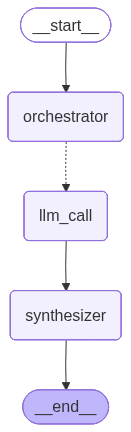

# 引言

目标检测是计算机视觉领域中的一项核心任务，旨在从图像或视频中识别并定位特定类别的物体。其基本目标是同时完成两个子任务：一是判断图像中是否存在感兴趣的目标对象，二是精确标定这些对象的位置，通常以边界框（bounding box）的形式表示。与图像分类仅关注“图像中有什么”不同，目标检测进一步回答“图像中的目标在哪里”，从而为更高层次的视觉理解提供空间信息支持。

目标检测在现实世界中具有广泛而重要的应用价值。例如，在自动驾驶系统中，准确检测行人、车辆和交通标志是保障行车安全的前提；在智能安防领域，实时检测异常行为或可疑物品有助于提升监控效率；在医疗影像分析中，目标检测可用于定位病灶区域，辅助医生进行诊断；此外，它还广泛应用于机器人导航、增强现实、工业质检以及遥感图像分析等多个场景。

近年来，随着深度学习技术的迅猛发展，尤其是卷积神经网络（CNN）和Transformer架构的引入，目标检测的精度与速度均取得了显著提升。从早期的两阶段方法（如R-CNN系列）到高效的单阶段模型（如YOLO、SSD），再到最新的端到端检测框架（如DETR），目标检测算法不断演进，推动了整个计算机视觉领域的进步。因此，深入理解目标检测的基本原理、关键技术及其发展趋势，对于推动智能视觉系统的发展具有重要意义。

---

# 目标检测的基本原理

目标检测是计算机视觉中的一项核心任务，旨在从图像或视频中识别出特定类别的物体，并精确地定位其在图像中的位置。其基本原理可以概括为两个紧密耦合的子任务：**分类（Classification）** 与 **定位（Localization）**。

首先，**分类任务**负责判断图像中是否存在预定义类别的目标（如人、车、猫等），并为每个检测到的目标分配一个类别标签。其次，**定位任务**则通过几何形状（通常为矩形框）标定目标在图像中的具体位置和范围。这两个任务必须同时完成，才能实现完整的目标检测功能。

在实际应用中，目标的位置通常使用**边界框（Bounding Box）** 来表示。边界框是一个包围目标对象的矩形区域，常用两种方式描述：  
1. **(x, y, w, h)**：其中 (x, y) 表示边界框左上角的坐标，w 和 h 分别表示其宽度和高度；  
2. **(x₁, y₁, x₂, y₂)**：其中 (x₁, y₁) 和 (x₂, y₂) 分别表示边界框左上角和右下角的坐标。

目标检测模型的核心思想在于，在输入图像中生成多个候选区域（Region Proposals）或直接在密集采样的位置上预测边界框及其对应的类别概率。现代目标检测方法大致可分为两类：  
- **两阶段检测器（Two-stage detectors）**：如 R-CNN 系列，首先生成候选区域，然后对每个区域进行分类和边界框回归；  
- **单阶段检测器（One-stage detectors）**：如 YOLO、SSD，在一次前向传播中直接预测类别和边界框。

无论采用哪种架构，目标检测系统最终输出的是一组带有类别标签和置信度得分的边界框，从而实现对图像中多个目标的同时识别与定位。这一结合分类与定位的机制，构成了目标检测技术的基础框架。

---

# 传统目标检测方法

在深度学习兴起之前，目标检测主要依赖于手工设计的特征与分类器相结合的策略。其中最具代表性的方法包括基于Haar特征的Viola-Jones框架、基于方向梯度直方图（Histogram of Oriented Gradients, HOG）特征配合支持向量机（SVM）的方法，以及普遍采用的滑动窗口（Sliding Window）检测机制。

Haar特征由Paul Viola和Michael Jones于2001年提出，通过计算图像局部区域的像素强度差异来捕捉边缘、线段和纹理等简单结构。结合积分图（Integral Image）加速计算、AdaBoost进行特征选择以及级联分类器结构，该方法在人脸检测任务中实现了实时性能，成为早期工业应用的主流方案。

HOG特征则由Dalal和Triggs于2005年提出，通过统计图像局部区域内梯度方向的分布来描述目标的形状和轮廓信息。HOG对光照变化和小幅度形变具有较强鲁棒性，通常与线性SVM分类器结合，广泛应用于行人检测等任务。

上述方法普遍依赖滑动窗口技术：在图像上以不同尺度和位置遍历窗口，对每个窗口提取特征并送入分类器判断是否包含目标。尽管该策略思路直观，但计算冗余高，且难以处理多尺度和密集目标场景。

传统方法的优点在于不依赖大规模标注数据，计算资源需求相对较低，且在特定任务（如正面人脸检测）上可达到较高精度。然而，其局限性也十分明显：手工特征表达能力有限，泛化能力弱，难以适应复杂背景、遮挡、姿态变化等真实场景；滑动窗口机制效率低下，检测速度受限；同时，特征提取与分类阶段分离，缺乏端到端优化，整体性能提升空间有限。这些缺陷促使研究界转向基于深度学习的端到端目标检测范式。

---

# 基于深度学习的目标检测方法

目标检测是计算机视觉中的核心任务之一，旨在识别图像中特定类别的物体并定位其位置。近年来，深度学习技术的迅猛发展极大地推动了目标检测性能的提升，催生了多种高效、准确的检测框架。当前主流的深度学习目标检测方法主要分为两类：两阶段（two-stage）方法和单阶段（one-stage）方法。

两阶段方法以区域提议（Region Proposal）为起点，首先生成候选目标区域，再对这些区域进行分类与边界框回归。代表性工作包括R-CNN、Fast R-CNN和Faster R-CNN系列。R-CNN首次将卷积神经网络（CNN）引入目标检测，通过选择性搜索（Selective Search）生成候选框，并对每个候选区域单独提取特征，计算开销大且效率低。Fast R-CNN在此基础上引入RoI Pooling层，实现共享卷积特征，显著提升了速度。Faster R-CNN进一步提出区域提议网络（Region Proposal Network, RPN），将候选框生成过程也纳入端到端训练，实现了更高的检测精度与效率。这类方法通常具有较高的检测精度，但推理速度相对较慢，适用于对精度要求严苛的场景。

相比之下，单阶段方法摒弃了区域提议步骤，直接在图像上进行密集预测，同时完成分类与定位任务，因此具有更快的推理速度。典型代表包括YOLO（You Only Look Once）系列和SSD（Single Shot MultiBox Detector）。YOLO将目标检测视为一个回归问题，将图像划分为网格，每个网格负责预测多个边界框及其类别概率，具有极高的实时性，但在小目标检测和定位精度方面存在局限。后续版本如YOLOv3、YOLOv4及YOLOv5通过引入多尺度预测、改进骨干网络和损失函数等方式不断提升性能。SSD则在不同尺度的特征图上进行检测，利用多尺度特征增强对不同大小目标的适应能力，在速度与精度之间取得了良好平衡。

总体而言，两阶段方法在精度上通常优于单阶段方法，而单阶段方法在推理速度上更具优势。随着模型压缩、知识蒸馏和新型网络架构的发展，两类方法之间的性能差距正在逐步缩小。在实际应用中，需根据具体任务对精度、速度和资源消耗的需求，合理选择合适的目标检测框架。

---

# 常用数据集与评估指标

在目标检测领域，研究人员和开发者广泛依赖标准化的数据集和评估指标来训练、验证和比较模型性能。以下介绍两个最具代表性的公开数据集以及核心的评估指标。

## 常用数据集

### PASCAL VOC（Visual Object Classes）
PASCAL VOC 是早期目标检测研究中使用最广泛的数据集之一，由欧洲 PASCAL 网络组织发布。其中 VOC2007 和 VOC2012 是最常用的版本。该数据集包含约 11,500 张图像，涵盖 20 个常见物体类别（如人、车、猫、狗等），每张图像都经过精细的边界框标注和类别标签。PASCAL VOC 数据集结构清晰，标注质量高，常用于算法原型验证和教学目的。

### COCO（Common Objects in Context）
COCO 是目前目标检测、实例分割和关键点检测等领域事实上的标准基准数据集，由微软团队于 2014 年发布。其规模远超 PASCAL VOC，包含超过 33 万张图像、200 多万个实例标注，覆盖 80 个物体类别。COCO 的显著特点是：  
- 图像场景复杂，强调物体在自然上下文中的出现；  
- 标注密集，单张图像常包含多个小目标或遮挡目标；  
- 提供多种任务标注（边界框、分割掩码、关键点等）。  
COCO 挑战赛（COCO Challenge）已成为衡量目标检测模型先进性的重要平台。

## 主要评估指标

### IoU（Intersection over Union）
IoU 是衡量预测边界框与真实边界框（Ground Truth）重合程度的基本指标，定义为两框交集面积与并集面积之比：
\[
\text{IoU} = \frac{\text{Area of Overlap}}{\text{Area of Union}}
\]
通常设定一个阈值（如 0.5），当预测框与真实框的 IoU 超过该阈值时，视为一次有效检测。

### mAP（mean Average Precision）
mAP 是目标检测中最核心的综合性能指标，用于衡量模型在不同召回率下的平均精度，并对所有类别取平均。具体计算过程如下：  
1. 对每个类别，根据模型输出的置信度对所有预测结果排序；  
2. 计算不同召回率下的精度，绘制 PR（Precision-Recall）曲线；  
3. 对 PR 曲线下面积进行插值或积分，得到该类别的 AP（Average Precision）；  
4. 对所有类别的 AP 取均值得到 mAP。  

在 COCO 评估协议中，mAP 进一步扩展为在多个 IoU 阈值（如从 0.5 到 0.95，步长 0.05）下的平均值，记作 mAP@[.5:.95]，更全面地反映模型在不同定位精度要求下的鲁棒性。相比之下，PASCAL VOC 通常采用单一 IoU 阈值（0.5）下的 mAP，即 mAP@0.5。

综上，PASCAL VOC 和 COCO 为算法研发提供了坚实的数据基础，而 IoU 与 mAP 则构成了目标检测模型性能评估的核心体系。

---

# 当前挑战与未来方向

目标检测作为计算机视觉领域的核心任务之一，尽管近年来取得了显著进展，但仍面临诸多关键挑战。其中，**小目标检测**问题尤为突出。由于小目标在图像中占据像素极少，其语义信息有限，容易被深层网络中的下采样操作所丢失，导致检测精度显著下降。此外，在遥感、医学影像和密集场景（如人群监控）等应用中，小目标普遍存在，进一步加剧了该问题的复杂性。

**遮挡问题**是另一大难点。现实场景中物体常被其他物体部分或完全遮挡，使得模型难以提取完整的外观特征，从而影响定位与分类的准确性。严重遮挡还可能导致误检或漏检，尤其在自动驾驶、智能安防等对鲁棒性要求极高的场景中，这一问题亟待解决。

除上述问题外，**类内差异大、类间相似度高**也给目标检测带来困难。例如，同一类别物体在不同姿态、光照或背景下的外观变化剧烈，而不同类别之间可能具有高度相似的纹理或形状，增加了模型判别的难度。同时，**实时性与精度之间的权衡**仍是实际部署中的瓶颈，尤其在边缘设备上，如何在有限算力下实现高效准确的检测仍具挑战。

展望未来，目标检测的研究趋势将围绕以下几个方向展开：  
1. **多模态融合**：结合红外、深度、文本等多源信息，提升在复杂环境下的感知能力，尤其有助于缓解遮挡和低光照条件下的检测难题。  
2. **自监督与弱监督学习**：减少对大规模标注数据的依赖，通过利用无标签或弱标签数据提升模型泛化能力，降低标注成本。  
3. **Transformer 与动态网络架构**：基于注意力机制的检测框架（如 DETR 及其变体）有望进一步优化长距离依赖建模；动态网络可根据输入内容自适应调整计算路径，兼顾效率与性能。  
4. **面向开放世界的检测**：突破传统封闭集假设，发展能够识别未知类别、持续学习新目标的检测系统，迈向更通用的视觉理解。  
5. **3D 与视频时序建模**：将目标检测从静态图像拓展至时空维度，利用时序一致性与几何结构信息提升检测鲁棒性，尤其适用于自动驾驶与机器人导航等场景。

综上所述，尽管当前目标检测技术已日趋成熟，但在复杂真实场景中的鲁棒性、泛化性与效率仍有较大提升空间。未来的研究将更加注重算法与实际应用的紧密结合，推动目标检测向更智能、更高效、更通用的方向发展。

---

# 总结

目标检测技术作为计算机视觉领域的核心任务之一，近年来取得了显著进展。从早期基于手工特征的方法（如HOG+SVM）到如今以深度学习为主导的两阶段（如Faster R-CNN）和单阶段（如YOLO、SSD）检测框架，算法在精度、速度与鲁棒性方面不断提升。特别是Transformer架构的引入（如DETR）以及多模态融合策略的发展，进一步拓展了目标检测的能力边界。

在实际应用中，目标检测已广泛服务于智能安防、自动驾驶、工业质检、医疗影像分析及人机交互等多个关键领域，展现出强大的实用价值和社会效益。然而，面对复杂场景下的小目标检测、遮挡处理、域泛化能力不足以及模型轻量化等挑战，现有方法仍存在改进空间。

因此，持续推动目标检测技术的基础研究与工程优化，不仅有助于提升算法在真实世界中的适应性和可靠性，也将为人工智能系统的整体智能化水平提供坚实支撑。未来的研究应更加注重算法效率与性能的平衡、对数据偏差的鲁棒性，以及在低资源环境下的部署能力，从而实现更广泛、更公平、更安全的应用落地。

In [20]:
from langgraph.types import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    #这里通过llm生成多个section，
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )
    #得到sections，每一个section都会被发送给llm生成内容，本方法内使用的是格式化llm形成的planner
    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    #这告诉 LangGraph 为 sections 列表里的每一个章节创建一个独立的执行任务。
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


# Build app
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the app
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the app
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic": "撰写一份关于目标检测的报告"})

from IPython.display import Markdown
Markdown(state["final_report"])